In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/
# python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
df = pd.read_csv('/kaggle/input/musait/all_info.csv')
df.head()

,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
0,negative_001.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,negative
1,negative_002.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative
2,negative_003.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.000000,negative
3,negative_004.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.000000,negative
4,negative_005.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative


# Feature analysis tables

In [3]:
# Create cross-tabulation table
sent_imgOr_table = pd.crosstab(df['sentiment'], df['img_or'])

print("____________________ Sentiment & Image Orientation contingency table ____________________")
print()
print(sent_imgOr_table)

____________________ Sentiment & Image Orientation contingency table ____________________

img_or     box  horizontal  other  vertical
sentiment                                  
negative   118         706     27        56
neutral    286         496     23       142
positive   323         311     15       372


In [4]:
# Create cross-tabulation table
sent_imgAr_table = pd.crosstab(df['sentiment'], df['img_ar'])

print("____________________ Sentiment & Image Aspect Ratio contingency table ____________________")
print()
print(sent_imgAr_table)

____________________ Sentiment & Image Aspect Ratio contingency table ____________________

img_ar     16:9  1:1  21:9  2:1  2:3  3:2  3:4  4:3  5:4  9:16  Other
sentiment                                                            
negative    472  118     3    2    0   63   55  161    5     1     27
neutral     308  286    10    6   11   59  126   97   16     5     23
positive    133  323     0    2    4   85  368   84    7     0     15


In [5]:
# Create cross-tabulation table
sent_txtOr_table = pd.crosstab(df['sentiment'], df['txt_or'])

print("____________________ Sentiment & Text Orientation contingency table ____________________")
print()
print(sent_txtOr_table)

____________________ Sentiment & Text Orientation contingency table ____________________

txt_or     box  horizontal  other  vertical
sentiment                                  
negative    96         439    264        63
neutral    153         325    277       145
positive   190         383    261       153


In [6]:
# Create cross-tabulation table
sent_txtAr_table = pd.crosstab(df['sentiment'], df['txt_ar'])

print("____________________ Sentiment & Text Aspect Ratio contingency table ____________________")
print()
print(sent_txtAr_table)

____________________ Sentiment & Text Aspect Ratio contingency table ____________________

txt_ar     16:9  1:1  21:9  2:1  2:3  2:5  3:2  3:4  4:3  5:4  9:16  Other
sentiment                                                                 
negative    194   96    49   25    5    1   64   54   98    9     3    264
neutral     108  153    58   28   24    8   43  104   74   14     9    277
positive     70  190    51   32   12    2   56  136  157   17     3    261


In [7]:
# Create cross-tabulation table
txtAr_imgAr_table = pd.crosstab(df['txt_ar'],df['img_ar'])

print("____________________ Text Aspect Ratio & Image Aspect Ratio contingency table ____________________")
print()
print(txtAr_imgAr_table)

____________________ Text Aspect Ratio & Image Aspect Ratio contingency table ____________________

img_ar  16:9  1:1  21:9  2:1  2:3  3:2  3:4  4:3  5:4  9:16  Other
txt_ar                                                            
16:9     270   22     0    0    2   12   34   20    3     0      9
1:1       48  271     1    0    0   20   65   26    5     0      3
21:9      85   23     2    0    0   13   17   12    1     0      5
2:1       52    8     0    0    0    4   16    4    0     0      1
2:3        4    8     0    0    6    4   19    0    0     0      0
2:5        0    1     0    0    1    0    5    0    0     4      0
3:2       49   32     0    0    3   30   13   34    0     0      2
3:4       17   69     2    0    2    4  184   15    0     1      0
4:3       53   91     0    0    0   32   43  102    2     0      6
5:4        5    9     0    0    1    4    5   11    5     0      0
9:16       1    8     0    0    0    1    4    0    0     1      0
Other    307  160     6    6 

In [8]:
# Create cross-tabulation table
txtOr_imgOr_table = pd.crosstab(df['txt_or'], df['img_or'])

print("____________________ Text Orientation & Image Orientation contingency table ____________________")
print()
print(txtOr_imgOr_table)

____________________ Text Orientation & Image Orientation contingency table ____________________

img_or      box  horizontal  other  vertical
txt_or                                      
box         271         100      3        65
horizontal  185         805     23       134
other       160         478     32       132
vertical     86          48      0       227


## Hypothesis Testing on Text Orientation

In [9]:
import os
from PIL import Image
from collections import defaultdict, Counter
from scipy.stats import chi2_contingency

import numpy as np
import pandas as pd

# Contingency table
# data = np.array([
#     [370, 242, 409],  # Positive
#     [53, 645, 209],   # Negative
#     [139, 419, 389]   # Neutral
# ])

data = sent_txtOr_table.copy()

# Optional: Set labels
sentiments = ['positive', 'negative', 'neutral']
orientations = ['box', 'horizontal', 'other', 'vertical']

# df = pd.DataFrame(data, index=sentiments, columns=orientations)
# Contingency table

# Chi-square test
chi2, p, dof, expected = chi2_contingency(data)

print(f"Chi-square statistic = {chi2:.3f}")
print(f"p-value = {p}")
print(f"Degrees of freedom = {dof}")

Chi-square statistic = 82.672
p-value = 1.0015599339976698e-15
Degrees of freedom = 6


In [11]:
sent_txtOr_table

txt_or,box,horizontal,other,vertical
sentiment,,,,
negative,96,439,264,63
neutral,153,325,277,145
positive,190,383,261,153


In [14]:
print("Expected frequencies (under H_0: No relationship):")
pd.DataFrame(np.round(expected, 2), index=sentiments, columns=orientations)

Expected frequencies (under H_0: No relationship):


,box,horizontal,other,vertical
positive,229.35,477.32,20.51,179.82
negative,239.47,498.37,21.41,187.75
neutral,258.18,537.31,23.08,202.42


In [16]:
print(f"p-value = {p}")
# Decision
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: There is a relationship between orientation and sentiment.")
else:
    print("Fail to reject the null hypothesis: No significant relationship found.")

p-value = 8.840667219230921e-111
Reject the null hypothesis: There is a relationship between orientation and sentiment.


## Hypothesis Testing on Image Orientation

In [17]:
import os
from PIL import Image
from collections import defaultdict, Counter
from scipy.stats import chi2_contingency

import numpy as np
import pandas as pd

# Contingency table
# data = np.array([
#     [370, 242, 409],  # Positive
#     [53, 645, 209],   # Negative
#     [139, 419, 389]   # Neutral
# ])

data = sent_imgOr_table.copy()

# Optional: Set labels
sentiments = ['positive', 'negative', 'neutral']
orientations = ['box', 'horizontal', 'other', 'vertical']

# df = pd.DataFrame(data, index=sentiments, columns=orientations)
# Contingency table

# Chi-square test
chi2, p, dof, expected = chi2_contingency(data)

print(f"Chi-square statistic = {chi2:.3f}")
print(f"p-value = {p}")
print(f"Degrees of freedom = {dof}")

Chi-square statistic = 527.746
p-value = 8.840667219230921e-111
Degrees of freedom = 6


In [18]:
print("Expected frequencies:")
pd.DataFrame(np.round(expected, 2), index=sentiments, columns=orientations)

Expected frequencies:


,box,horizontal,other,vertical
positive,229.35,477.32,20.51,179.82
negative,239.47,498.37,21.41,187.75
neutral,258.18,537.31,23.08,202.42


In [19]:
print(f"p-value = {p}")
# Decision
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: There is a relationship between orientation and sentiment.")
else:
    print("Fail to reject the null hypothesis: No significant relationship found.")

p-value = 8.840667219230921e-111
Reject the null hypothesis: There is a relationship between orientation and sentiment.


## Hypothesis Testing on Text-Image Ratio

In [20]:
type(df['txt_img_ratio'][0])

numpy.float64

In [21]:
import pandas as pd
import numpy as np

# Example: Ensure the column is numeric
col = pd.to_numeric(df['txt_img_ratio'], errors='coerce')

# Define bins (10 equal-width bins between 0 and 1)
bins = np.linspace(0, 1, 11)  # 11 edges = 10 bins
labels = [f"{round(bins[i],1)}–{round(bins[i+1],1)}" for i in range(len(bins)-1)]

# Add binned column
txt_img_bin = pd.cut(col, bins=bins, labels=labels, include_lowest=True)
df = pd.concat([df.iloc[:,:-1], txt_img_bin, df.iloc[:,-1]], axis=1)

In [22]:
df.columns.values[-2] = 'txt_img_ratio_bin'

In [23]:
df.head()

,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,txt_img_ratio_bin,sentiment
0,negative_001.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,0.2–0.3,negative
1,negative_002.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,0.3–0.4,negative
2,negative_003.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.000000,0.0–0.1,negative
3,negative_004.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.000000,0.0–0.1,negative
4,negative_005.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,0.3–0.4,negative


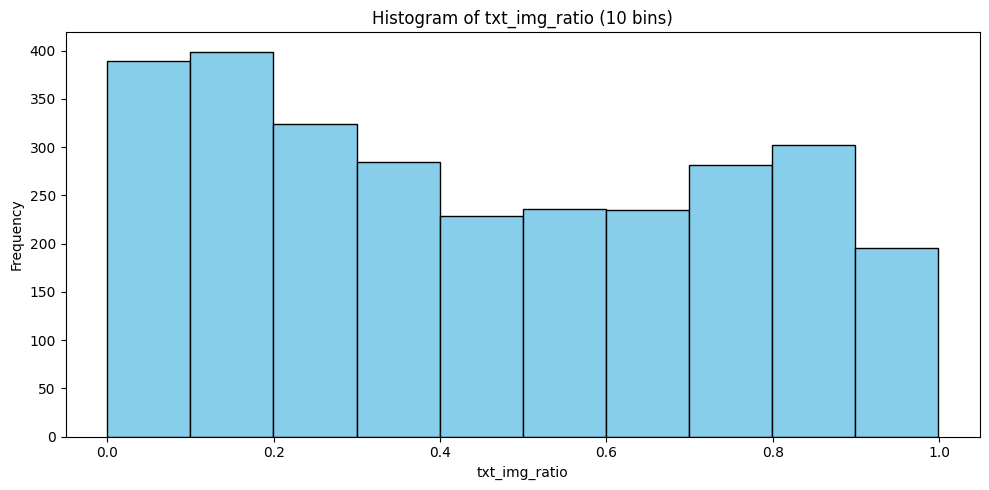

In [24]:
import matplotlib.pyplot as plt

# Plot histogram directly from the data
plt.figure(figsize=(10, 5))
plt.hist(df['txt_img_ratio'], bins=10, color='skyblue', edgecolor='black')

plt.xlabel('txt_img_ratio')
plt.ylabel('Frequency')
plt.title('Histogram of txt_img_ratio (10 bins)')
plt.tight_layout()
plt.savefig("txt_img_ratio.png")
plt.show()

In [25]:
# Create cross-tabulation table
sent_ratioBin_table = pd.crosstab(df['sentiment'], df['txt_img_ratio_bin'])

print("____________________ Text Orientation & Image Orientation contingency table ____________________")
print()
sent_ratioBin_table

____________________ Text Orientation & Image Orientation contingency table ____________________



txt_img_ratio_bin,0.0–0.1,0.1–0.2,0.2–0.3,0.3–0.4,0.4–0.5,0.5–0.6,0.6–0.7,0.7–0.8,0.8–0.9,0.9–1.0
sentiment,,,,,,,,,,
negative,96,112,72,63,49,68,107,98,142,100
neutral,153,112,83,93,63,76,77,122,104,64
positive,140,177,168,128,117,92,54,61,55,29


In [26]:
labels

['0.0–0.1',
 '0.1–0.2',
 '0.2–0.3',
 '0.3–0.4',
 '0.4–0.5',
 '0.5–0.6',
 '0.6–0.7',
 '0.7–0.8',
 '0.8–0.9',
 '0.9–1.0']

In [27]:
import os
from PIL import Image
from collections import defaultdict, Counter
from scipy.stats import chi2_contingency

import numpy as np
import pandas as pd

# Contingency table
# data = np.array([
#     [370, 242, 409],  # Positive
#     [53, 645, 209],   # Negative
#     [139, 419, 389]   # Neutral
# ])

data = sent_ratioBin_table.copy()

# Optional: Set labels
sentiments = ['positive', 'negative', 'neutral']
labels = ['0.0–0.1', '0.1–0.2', '0.2–0.3', '0.3–0.4', '0.4–0.5', '0.5–0.6', 
          '0.6–0.7', '0.7–0.8', '0.8–0.9', '0.9–1.0']

# df = pd.DataFrame(data, index=sentiments, columns=orientations)
# Contingency table

# Chi-square test
chi2, p, dof, expected = chi2_contingency(data)

print(f"Chi-square statistic = {chi2:.3f}")
print(f"p-value = {p}")
print(f"Degrees of freedom = {dof}")

Chi-square statistic = 250.960
p-value = 5.201173613652218e-43
Degrees of freedom = 18


In [28]:
print("Expected frequencies:")
pd.DataFrame(np.round(expected, 2), index=sentiments, columns=labels)

Expected frequencies:


,0.0–0.1,0.1–0.2,0.2–0.3,0.3–0.4,0.4–0.5,0.5–0.6,0.6–0.7,0.7–0.8,0.8–0.9,0.9–1.0
positive,122.72,126.51,101.90,89.60,72.24,74.45,75.08,88.65,94.96,60.89
negative,128.13,132.09,106.39,93.55,75.43,77.74,78.40,92.56,99.15,63.57
neutral,138.15,142.41,114.71,100.86,81.32,83.81,84.52,99.79,106.89,68.54


In [29]:
print(f"p-value = {p}")
# Decision
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: There is a relationship between txt_img_ratio and sentiment.")
else:
    print("Fail to reject the null hypothesis: No significant relationship found.")

p-value = 5.201173613652218e-43
Reject the null hypothesis: There is a relationship between txt_img_ratio and sentiment.


In [30]:
df.to_csv("all_info.csv", index=False)